In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [9]:
df = pd.read_csv('exchange_rate.csv')
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [12]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')

In [14]:
df.set_index('date', inplace=True)

In [15]:
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


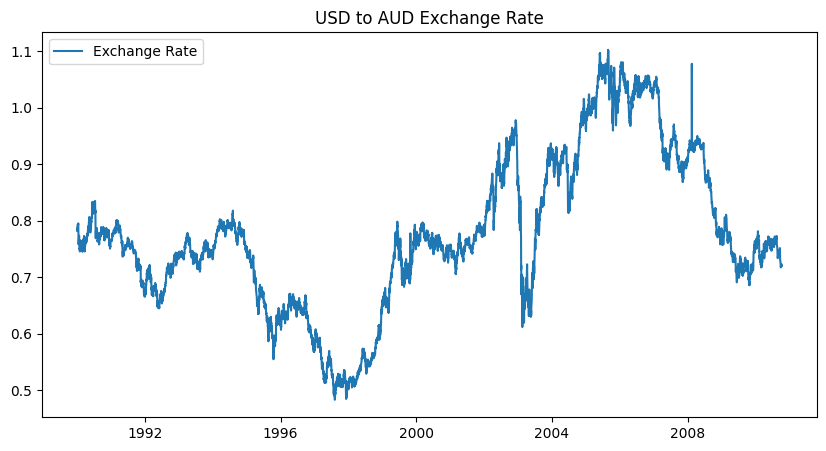

In [16]:
plt.figure(figsize=(10,5))
plt.plot(df.iloc[:,0], label='Exchange Rate')
plt.title("USD to AUD Exchange Rate")
plt.legend()
plt.show()

In [17]:
print(df.isnull().sum())

Ex_rate    0
dtype: int64


In [18]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_2879/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [19]:
train_size = int(len(df)*0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

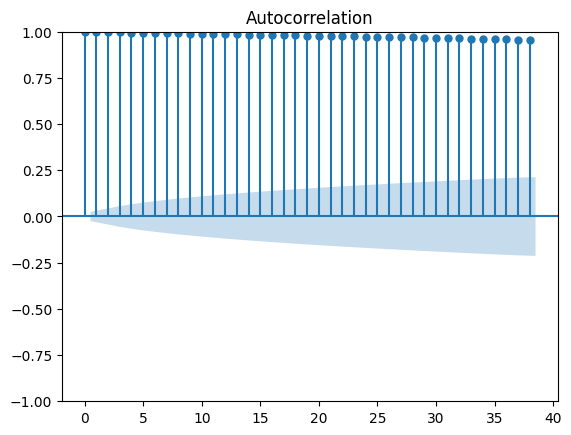

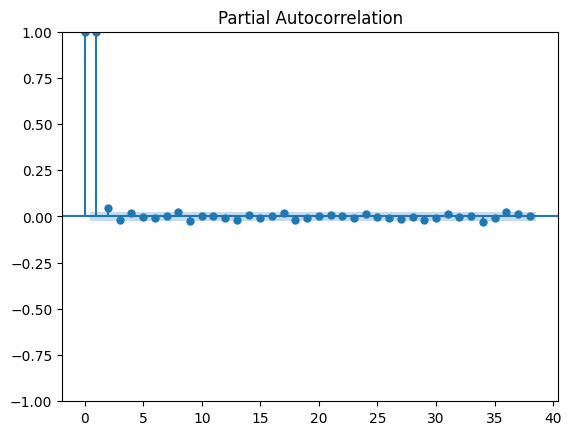

In [20]:
plot_acf(train.iloc[:,0])
plot_pacf(train.iloc[:,0])
plt.show()

ACF → helps find q

PACF → helps find p

If data not stationary → use differencing (d)

In [22]:
model_arima = ARIMA(train.iloc[:,0], order=(1,1,1))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [23]:
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Wed, 01 Apr 2026   AIC                         -45432.092
Time:                        11:58:10   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

In [24]:
forecast_arima = model_arima_fit.forecast(steps=len(test))

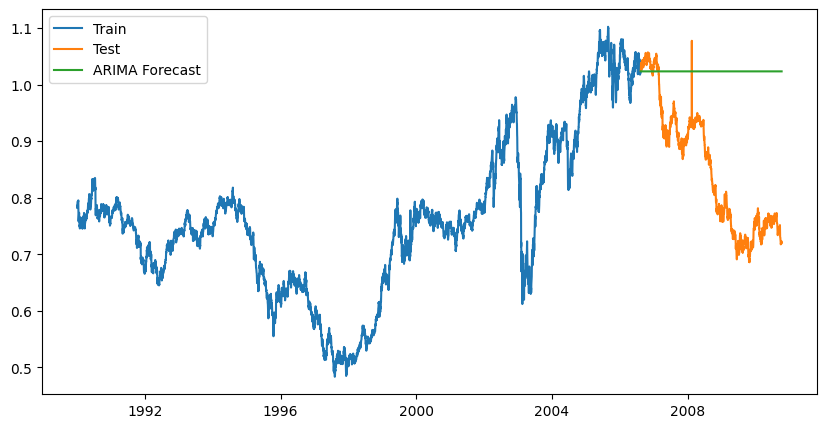

In [25]:
plt.figure(figsize=(10,5))
plt.plot(train.index, train.iloc[:,0], label='Train')
plt.plot(test.index, test.iloc[:,0], label='Test')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast')
plt.legend()
plt.show()

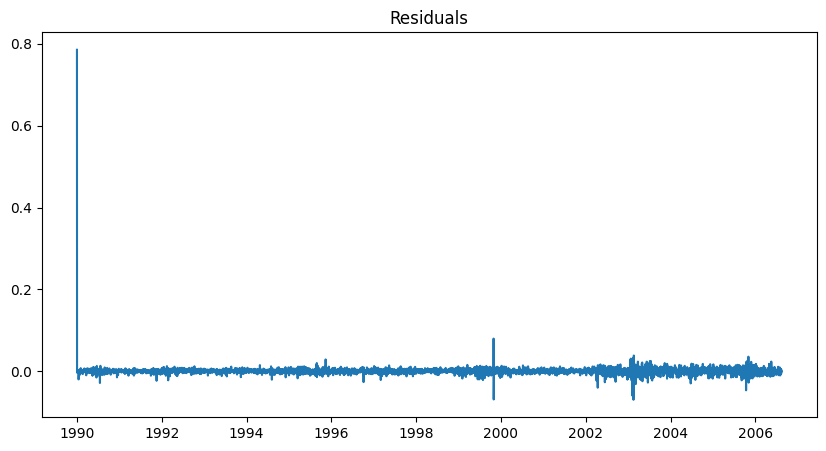

In [26]:
residuals = model_arima_fit.resid

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

In [27]:
model_es = ExponentialSmoothing(
    train.iloc[:,0],
    trend='add',
    seasonal=None
)

model_es_fit = model_es.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


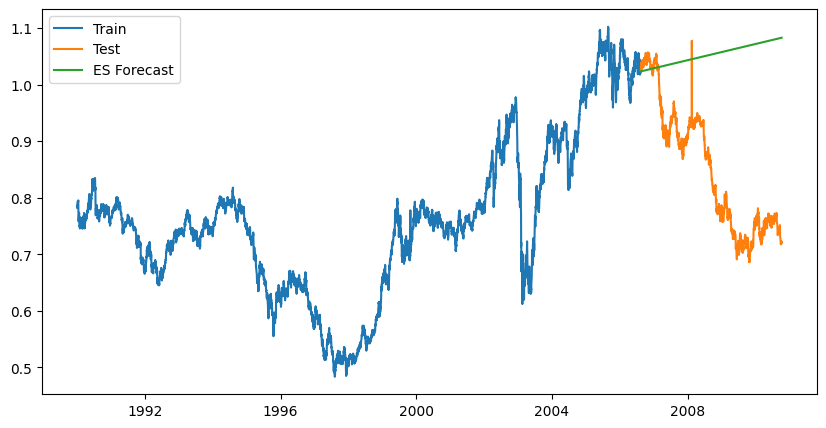

In [28]:
forecast_es = model_es_fit.forecast(steps=len(test))

plt.figure(figsize=(10,5))
plt.plot(train.index, train.iloc[:,0], label='Train')
plt.plot(test.index, test.iloc[:,0], label='Test')
plt.plot(test.index, forecast_es, label='ES Forecast')
plt.legend()
plt.show()

In [29]:
def evaluate(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape

In [32]:
mae_a, rmse_a, mape_a = evaluate(test.iloc[:,0], forecast_arima)
print("ARIMA -> MAE:", mae_a, "RMSE:", rmse_a, "MAPE:", mape_a)

ARIMA -> MAE: 0.17770970449121345 RMSE: 0.2054366965966928 MAPE: 22.797966173811552


In [36]:
mae_e, rmse_e, mape_e = evaluate(test.iloc[:,0], forecast_es)
print("ES -> MAE:", mae_e, "RMSE:", rmse_e, "MAPE:", mape_e)

ES -> MAE: 0.20659619114093827 RMSE: 0.23910443161792286 MAPE: 26.50866379878783


## Model Comparison

- ARIMA captures patterns using autoregression and moving averages.
- Exponential Smoothing focuses on trend and level.

### Observations:
- Compare MAE, RMSE, MAPE values
- Lower values indicate better model

### Conclusion:
- The model with lowest error metrics performs best.

## Conclusion

- Both ARIMA and Exponential Smoothing were applied.
- ARIMA works well for stationary data.
- Exponential Smoothing works well for trend-based data.

Final model selection depends on error metrics.